# Weather — Exploratory Analysis

## Objective
Characterise the merged temperature/irradiance series before it is cleaned and
modelled: data quality, distribution shape, seasonality, and the inter-annual
trends that motivate specific choices in the downstream models. Each section
below is kept only where it explains or motivates a decision made in
`Code/Transformation/02_weather.ipynb` or `Code/Modelling/Solar Irradiation
model.ipynb` / `Temperature model.ipynb` — exploratory dead ends (e.g. hot/cold
day counts, which no downstream notebook uses) have been removed.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Interim/df_bologna_full.parquet` (pre-cleaning merge) | Exploratory analysis | (none persisted) |

**This notebook is terminal** for the pipeline (nothing downstream reads it),
and writes no artifacts to disk: its figures are displayed inline, and its
findings motivate specific modelling choices noted inline.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import logit
from scipy.stats import gaussian_kde


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "Code").is_dir() and (cand / "Data").is_dir():
            return cand
    raise RuntimeError(f"Project root not found above {here}")


ROOT = find_project_root()
RESULTS_DIR = ROOT / "Data" / "Results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df = pd.read_parquet(ROOT / "Data" / "Interim" / "df_bologna_full.parquet")
df = df.sort_values("time").reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Range : {df['time'].min()}  ->  {df['time'].max()}")
print(df.dtypes)

Shape : (184079, 7)
Range : 2005-01-01 01:00:00  ->  2025-12-31 23:00:00
time             datetime64[ns]
latitude                float64
longitude               float64
t2m                     float32
SSRD_Wm2                float32
CLEAR_SKY_GHI           float64
GHI                     float64
dtype: object


## Data Quality

**What to look for:** whether the hourly index is complete and regular, and
where the missing `GHI` hours actually fall — this is the evidence behind the
three imputation rules in `Code/Transformation/02_weather.ipynb`.

In [2]:
full_index = pd.date_range(df["time"].min(), df["time"].max(), freq="h")
n_dup      = df["time"].duplicated().sum()
n_missing  = len(full_index) - len(df)

print(f"Expected hourly steps : {len(full_index):,}")
print(f"Actual rows           : {len(df):,}")
print(f"Duplicate timestamps  : {n_dup:,}")
print(f"Missing hourly steps  : {n_missing:,}")

t2m_spikes = (df["t2m"].diff().abs() > 10).sum()
print()
print(f"Temperature jumps > 10K in 1h : {t2m_spikes:,}")

for c in ["SSRD_Wm2", "CLEAR_SKY_GHI", "GHI"]:
    below, above = (df[c] < 0).sum(), (df[c] > 1400).sum()
    print(f"{c:15s} bounds [0, 1400] W/m2 -- below: {below}, above: {above}")

overshoot = (df.loc[df["CLEAR_SKY_GHI"] > 0, "GHI"] > df.loc[df["CLEAR_SKY_GHI"] > 0, "CLEAR_SKY_GHI"]).mean()
print(f"Daytime hours where GHI > CLEAR_SKY_GHI : {overshoot:.2%}  (cloud-enhancement, not a defect)")


Expected hourly steps : 184,079
Actual rows           : 184,079
Duplicate timestamps  : 0
Missing hourly steps  : 0

Temperature jumps > 10K in 1h : 0
SSRD_Wm2        bounds [0, 1400] W/m2 -- below: 2, above: 0
CLEAR_SKY_GHI   bounds [0, 1400] W/m2 -- below: 0, above: 0
GHI             bounds [0, 1400] W/m2 -- below: 0, above: 0
Daytime hours where GHI > CLEAR_SKY_GHI : 0.00%  (cloud-enhancement, not a defect)


Days with a missing GHI hour: 5


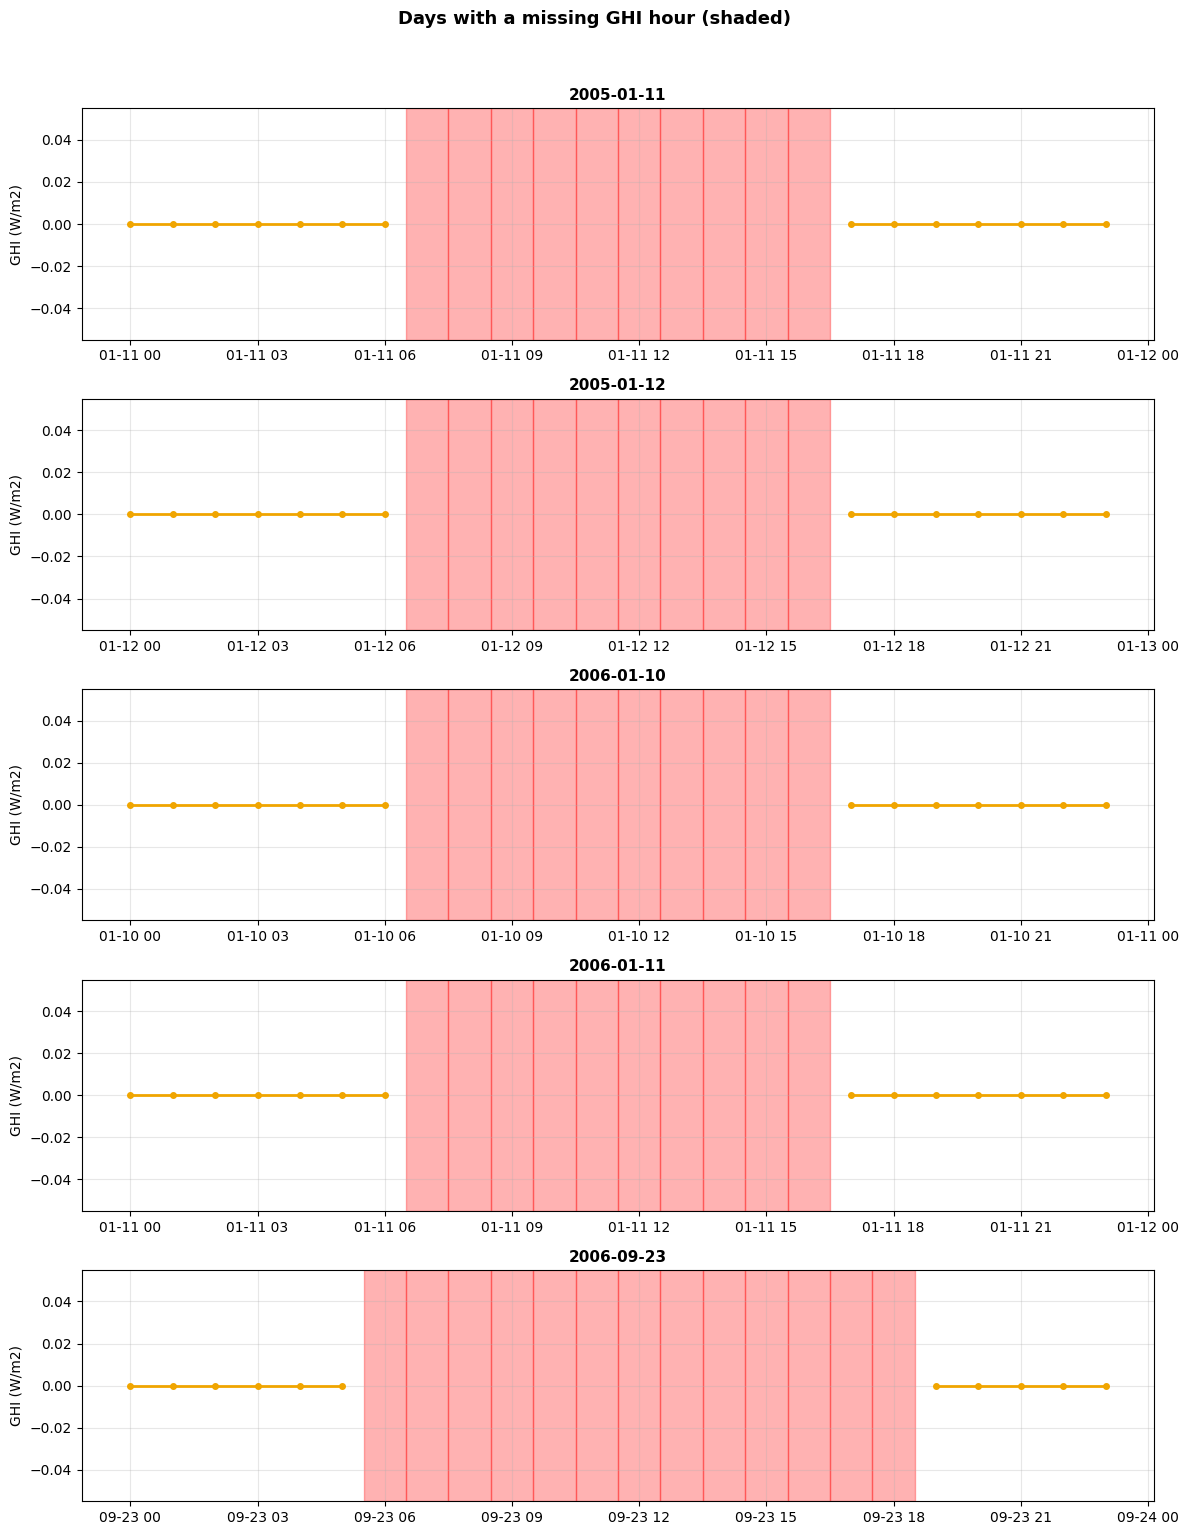

In [3]:
missing_dates = df.loc[df["GHI"].isna(), "time"].dt.date.unique()
print(f"Days with a missing GHI hour: {len(missing_dates)}")

df["date"] = df["time"].dt.date
plot_data  = df[df["date"].isin(missing_dates)]

fig, axes = plt.subplots(len(missing_dates), 1, figsize=(12, 3 * len(missing_dates)))
axes = [axes] if len(missing_dates) == 1 else axes

for ax, date in zip(axes, missing_dates):
    day = plot_data[plot_data["date"] == date]
    ax.plot(day["time"], day["GHI"], color="#f0a500", lw=2, marker="o", markersize=4, label="GHI")
    for ts in day.loc[day["GHI"].isna(), "time"]:
        ax.axvspan(ts - pd.Timedelta(minutes=30), ts + pd.Timedelta(minutes=30), color="red", alpha=0.3)
    ax.set_title(str(date), fontsize=11, fontweight="bold")
    ax.set_ylabel("GHI (W/m2)")
    ax.grid(alpha=0.3)

plt.suptitle("Days with a missing GHI hour (shaded)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

df = df.drop(columns="date")

> **Takeaway.** The hourly index is complete and regular (no gaps, no
> duplicates), and every physical bound holds. The handful of missing `GHI`
> hours are isolated within otherwise-observed days — exactly the case
> Transformation's daily-clearness-ratio rule (D4) is built for, not a
> whole-day gap needing the clear-sky fallback (D5).

## Distributions

**What to look for:** whether temperature is roughly symmetric while solar
variables are bounded and skewed — this is why the solar model applies a logit
transform to `Kt` and temperature does not.

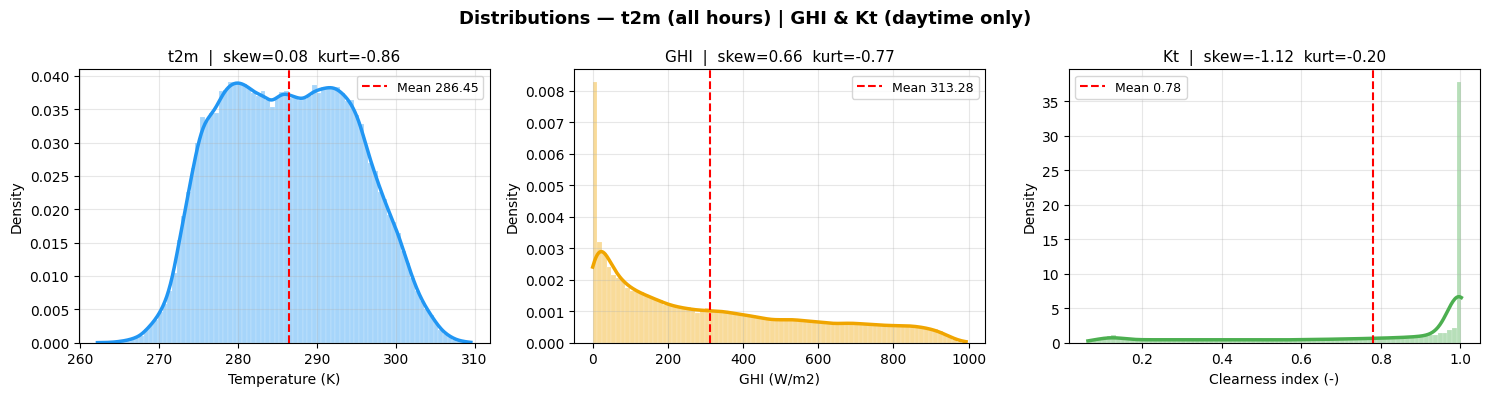

In [4]:
df_day = df[df["GHI"] > 0].copy()
df_day["Kt"] = df_day["GHI"] / df_day["CLEAR_SKY_GHI"]

variables = [
    {"col": "t2m", "data": df,     "label": "Temperature (K)",     "color": "#2196F3"},
    {"col": "GHI", "data": df_day, "label": "GHI (W/m2)",          "color": "#f0a500"},
    {"col": "Kt",  "data": df_day, "label": "Clearness index (-)", "color": "#4CAF50"},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables):
    data = var["data"][var["col"]].dropna()
    ax.hist(data, bins=80, color=var["color"], alpha=0.4, edgecolor="white", linewidth=0.3, density=True)
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 400)
    ax.plot(x, kde(x), color=var["color"], lw=2.5)
    ax.axvline(data.mean(), color="red", lw=1.5, linestyle="--", label=f"Mean {data.mean():.2f}")
    ax.set_title(f"{var['col']}  |  skew={data.skew():.2f}  kurt={data.kurt():.2f}", fontsize=11)
    ax.set_xlabel(var["label"]); ax.set_ylabel("Density"); ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Distributions — t2m (all hours) | GHI & Kt (daytime only)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> **Takeaway.** Temperature is close to symmetric (low skew), consistent with
> the additive Fourier + AR(2) form used in `Temperature model.ipynb`. `Kt` is
> bounded in (0, 1] and left-skewed (mass near clear-sky), which is exactly
> what motivates the logit transform in `Solar Irradiation model.ipynb` —
> modelling `Kt` directly on its natural scale would let a Gaussian
> innovation put probability mass outside the physical range.

## Seasonality

**What to look for:** how strongly each variable varies by calendar month —
the shape the models' seasonal terms (Fourier harmonics, monthly GMM) have to
reproduce.

In [5]:
df_daily = (
    df.groupby(df["time"].dt.date)
    .agg(t2m_mean=("t2m", "mean"), GHI_sum=("GHI", "sum"),
         GHI_cs_sum=("CLEAR_SKY_GHI", "sum"), GHI_var=("GHI", "var"))
    .assign(Kt_daily=lambda x: x["GHI_sum"] / x["GHI_cs_sum"])
    .rename_axis("date").reset_index()
)
df_daily["date"]  = pd.to_datetime(df_daily["date"])
df_daily["month"] = df_daily["date"].dt.month
df_daily["year"]  = df_daily["date"].dt.year

print(f"Daily series: {df_daily.shape[0]:,} days, {df_daily['year'].nunique()} years")

Daily series: 7,670 days, 21 years


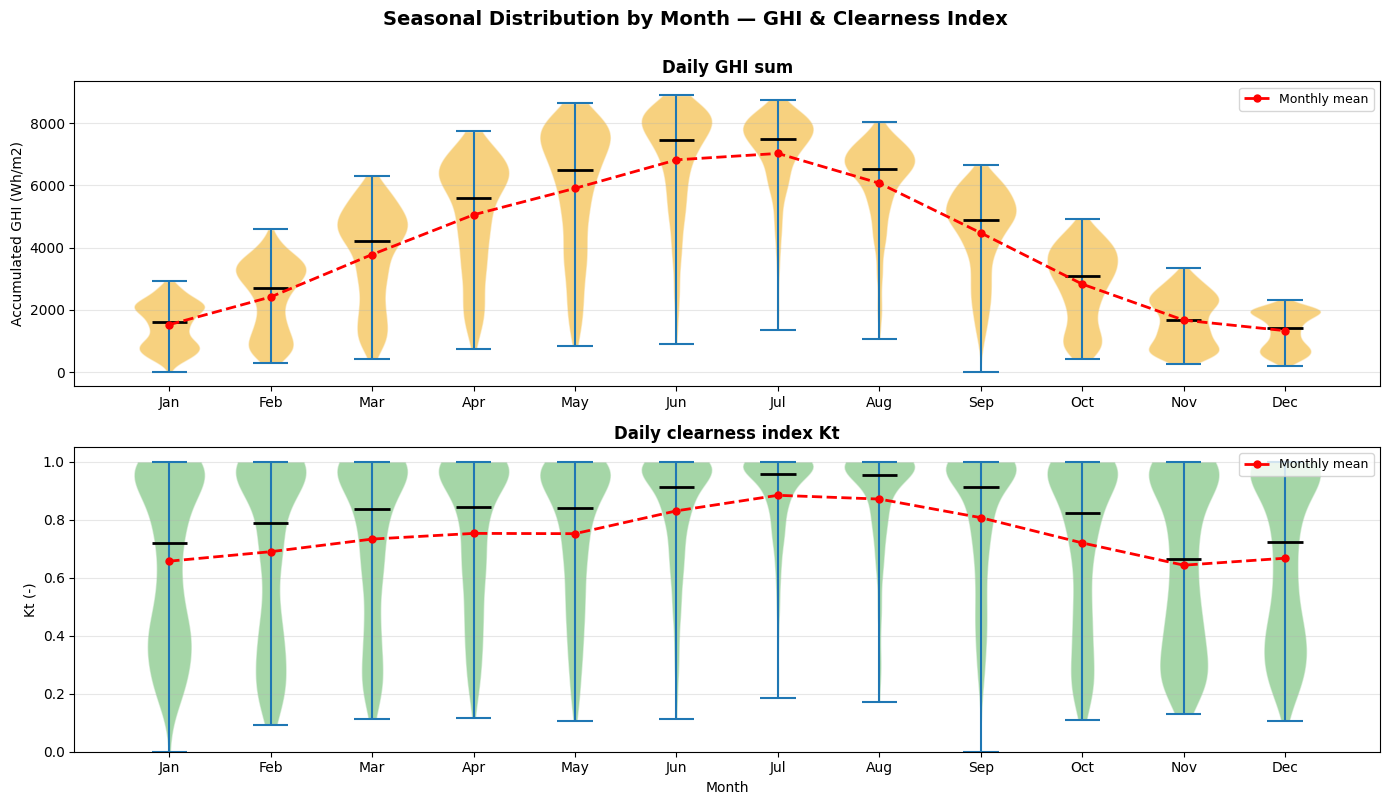

[SAVED] fig_ghi_kt_monthly_violin.png / .pdf


In [6]:
def violin_panel(ax, values_by_month, color, title, ylabel):
    parts = ax.violinplot(values_by_month, positions=range(1, 13), showmedians=True, showextrema=True, widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor(color); pc.set_alpha(0.5); pc.set_edgecolor("white")
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
    means = [v.mean() if len(v) else np.nan for v in values_by_month]
    ax.plot(range(1, 13), means, color="red", lw=2, marker="o", markersize=5, linestyle="--", label="Monthly mean")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_LABELS)
    ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3, axis="y")


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
ghi_by_month = [df_daily.loc[df_daily["month"] == m, "GHI_sum"].dropna().values for m in range(1, 13)]
kt_by_month  = [df_daily.loc[df_daily["month"] == m, "Kt_daily"].dropna().values for m in range(1, 13)]
violin_panel(axes[0], ghi_by_month, "#f0a500", "Daily GHI sum", "Accumulated GHI (Wh/m2)")
violin_panel(axes[1], kt_by_month,  "#4CAF50", "Daily clearness index Kt", "Kt (-)")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("Month")

plt.suptitle("Seasonal Distribution by Month — GHI & Clearness Index", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

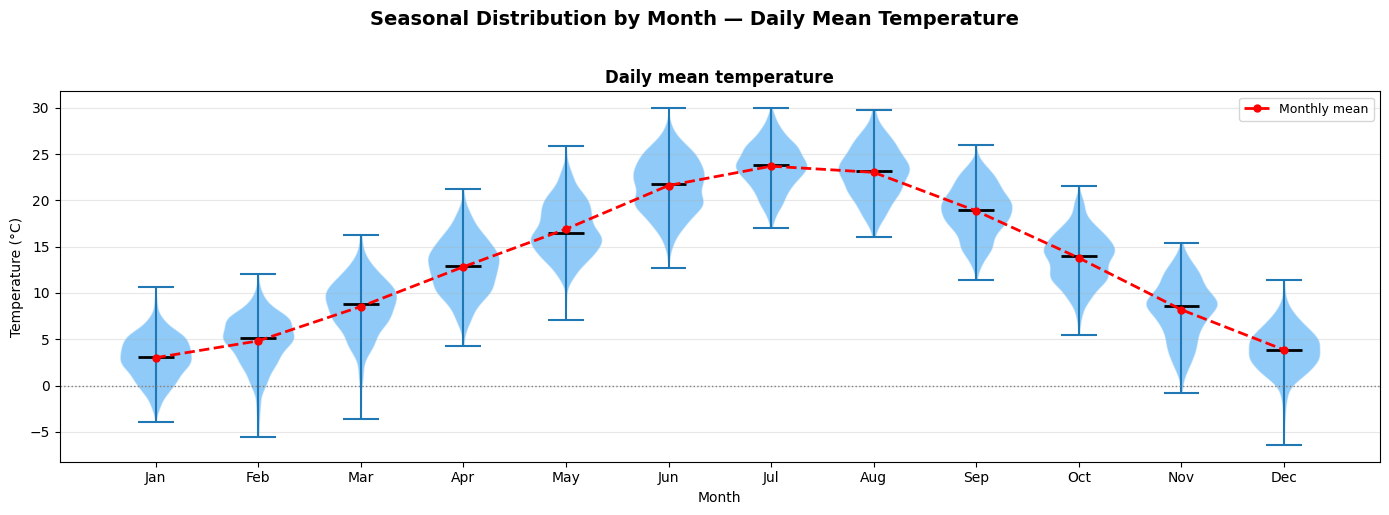

[SAVED] fig_t2m_monthly_violin.png / .pdf


In [7]:
t2m_by_month = [
    (df_daily.loc[df_daily["month"] == m, "t2m_mean"] - 273.15).dropna().values
    for m in range(1, 13)
]

fig, ax = plt.subplots(figsize=(14, 5))
violin_panel(ax, t2m_by_month, "#2196F3", "Daily mean temperature", "Temperature (°C)")
ax.axhline(0, color="grey", lw=1, linestyle=":")
ax.set_xlabel("Month")

plt.suptitle("Seasonal Distribution by Month — Daily Mean Temperature", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> **Takeaway.** GHI and Kt both show a clean single annual cycle, peaking in
> summer — well captured by one harmonic plus a monthly GMM (which absorbs
> the residual month-to-month spread the single harmonic cannot). Temperature
> shows the same one-cycle shape, matching the Fourier(3) term in the
> temperature model.

## Inter-Annual Trends

**What to look for:** whether each variable is trending over the 21-year
sample — a real trend has to be modelled explicitly (as the temperature model
does) rather than left for a stationary model to absorb.

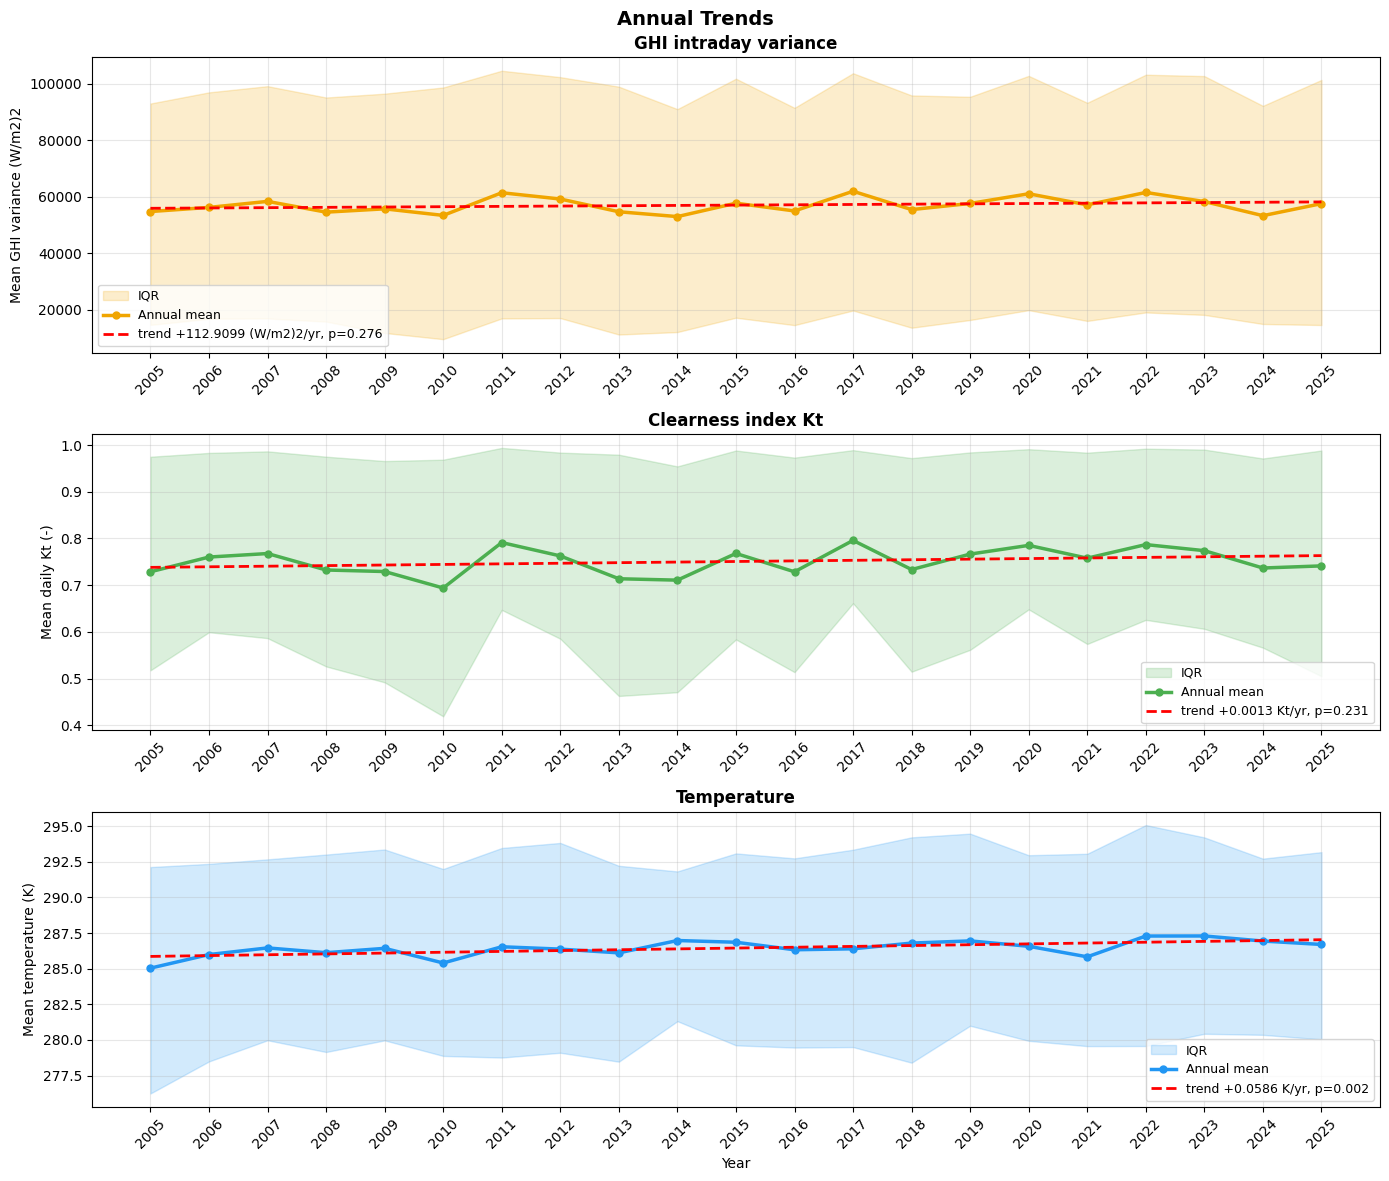

GHI variance trend : +112.910 (W/m2)2/yr, p=0.2765
Kt trend            : +0.001258 Kt/yr,        p=0.2313
Temperature trend   : +0.0586 K/yr,         p=0.0018


In [8]:
def annual_trend_panel(ax, daily_col, color, ylabel, unit):
    ann = df_daily.groupby("year")[daily_col].agg(mean="mean", q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75))
    years, means = ann.index.values, ann["mean"].values
    slope, intercept, r, p, se = stats.linregress(years, means)

    ax.fill_between(years, ann["q25"], ann["q75"], color=color, alpha=0.2, label="IQR")
    ax.plot(years, means, color=color, lw=2.5, marker="o", markersize=5, label="Annual mean")
    ax.plot(years, intercept + slope * years, color="red", lw=2, linestyle="--",
            label=f"trend {slope:+.4f} {unit}/yr, p={p:.3f}")
    ax.set_ylabel(ylabel); ax.set_xticks(years); ax.set_xticklabels(years, rotation=45)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    return slope, p


fig, axes = plt.subplots(3, 1, figsize=(14, 12))
s_ghi, p_ghi = annual_trend_panel(axes[0], "GHI_var",  "#f0a500", "Mean GHI variance (W/m2)2", "(W/m2)2")
s_kt,  p_kt  = annual_trend_panel(axes[1], "Kt_daily",  "#4CAF50", "Mean daily Kt (-)",          "Kt")
s_t2m, p_t2m = annual_trend_panel(axes[2], "t2m_mean",  "#2196F3", "Mean temperature (K)",       "K")
axes[0].set_title("GHI intraday variance", fontweight="bold")
axes[1].set_title("Clearness index Kt", fontweight="bold")
axes[2].set_title("Temperature", fontweight="bold")
axes[2].set_xlabel("Year")

plt.suptitle("Annual Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"GHI variance trend : {s_ghi:+.3f} (W/m2)2/yr, p={p_ghi:.4f}")
print(f"Kt trend            : {s_kt:+.6f} Kt/yr,        p={p_kt:.4f}")
print(f"Temperature trend   : {s_t2m:+.4f} K/yr,         p={p_t2m:.4f}")

> **Takeaway.** Temperature has a statistically significant upward trend
> (+0.059 K/yr, p = 0.002) -- the direct empirical basis for the linear trend
> term fitted in `Temperature model.ipynb`, and it lines up almost exactly
> with the 0.0585 C/yr the model actually fits (see `MODEL_SPECS.md`). `Kt`
> and GHI variance show no significant linear trend (p = 0.23 and p = 0.28) --
> consistent with `Insights.txt`'s note that GHI "does not change much during
> the years" on average. The IQR bands in the chart above are still visibly
> different width from year to year, though, which is exactly why the solar
> model fits a full distribution (the monthly GMM) rather than assuming
> constant year-to-year variance.


## Clearness Index Transform Preview

**What to look for:** whether a logit transform of `Kt_daily` looks closer to
symmetric than `Kt_daily` itself — this is the transform
`Solar Irradiation model.ipynb` fits its ARMA(2,1) on.

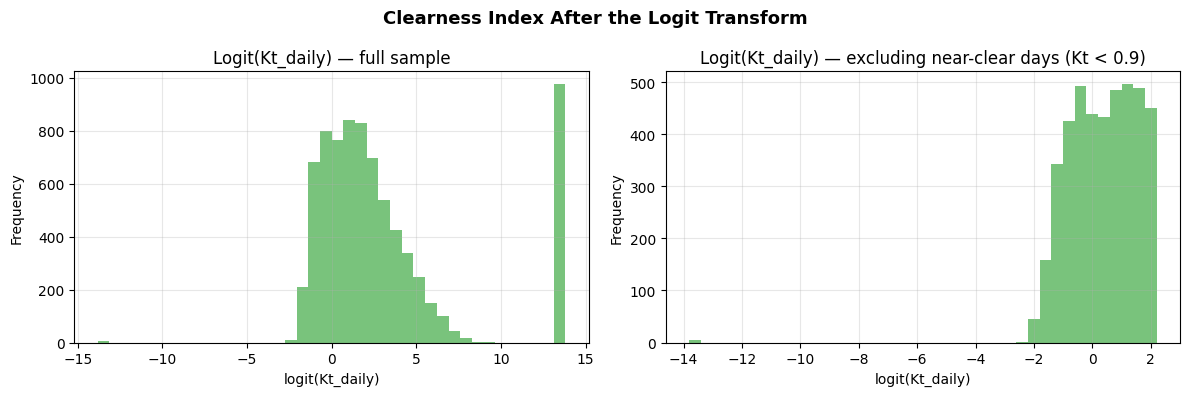

In [9]:
df_daily["Kt_logit"] = logit(df_daily["Kt_daily"].clip(1e-6, 1 - 1e-6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_daily["Kt_logit"], bins=40, color="#4CAF50", alpha=0.75)
axes[0].set_title("Logit(Kt_daily) — full sample")
axes[1].hist(df_daily.loc[df_daily["Kt_daily"] < 0.9, "Kt_logit"], bins=40, color="#4CAF50", alpha=0.75)
axes[1].set_title("Logit(Kt_daily) — excluding near-clear days (Kt < 0.9)")
for ax in axes:
    ax.set_xlabel("logit(Kt_daily)"); ax.set_ylabel("Frequency"); ax.grid(alpha=0.3)

plt.suptitle("Clearness Index After the Logit Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> **Takeaway.** The full-sample histogram is bimodal (a clear-sky mode near
> the upper bound and an overcast mode below it) even after the logit
> transform — exactly why the solar model does not stop at a single Gaussian
> innovation and instead fits a two-component GMM per month on top of the
> ARMA residual.

## Conclusion & Handoff

- The hourly series is complete and physically bounded; the few missing `GHI`
  hours are isolated, supporting Transformation's ratio-based fill rather
  than the whole-day clear-sky fallback.
- `Kt` is left-skewed and bimodal even after a logit transform — the direct
  motivation for the solar model's monthly two-component GMM.
- Temperature trends upward over the sample; `Kt`'s mean is flat but its
  year-to-year variance is not, both empirical facts the respective models
  are built to capture rather than assume away.

**Next notebook can rely on:** the two exported figures in `Data/Results/`;
nothing downstream reads this notebook's data outputs directly — it is
motivating context for `Code/Modelling/Solar Irradiation model.ipynb` and
`Code/Modelling/Temperature model.ipynb`.